# Predictive Model — Next-Day Trader Profitability
**Primetrade Data Science Assignment**

---

## Objective

We build a binary classifier that predicts whether a trader will have a
**profitable day tomorrow** based on today's market sentiment and trading
behavior. This is useful because it lets traders adjust position sizing or
sit out when the model signals a likely losing day.

**Target variable:** `1` = profitable day (daily PnL > 0), `0` = losing day.

**Model:** Random Forest Classifier — an ensemble of decision trees that vote
together. It handles mixed feature types, requires no manual feature scaling,
and provides built-in feature importance.

### Notebook Structure
1. Data Loading & Preprocessing
2. Feature Engineering
3. Encoding & Scaling
4. Train/Test Split (time-based)
5. Model Training
6. Evaluation & Confusion Matrix
7. Feature Importance
8. Insights

---
## Section 1 — Imports and Data Loading

In [7]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)

sns.set_theme(style='darkgrid', palette='husl', font_scale=1.1)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('All libraries imported successfully.')

All libraries imported successfully.


### 1.1 — Load and preprocess both datasets

We replicate the same cleaning steps from the analysis notebook:
parse dates, drop redundant columns, rename to snake_case, and merge
with sentiment labels.

In [8]:
# ── Load raw data ────────────────────────────────────────────────────────────
df_sentiment = pd.read_csv('../data/sentiment.csv')
df_trades    = pd.read_csv('../data/traders.csv')

# ── Parse dates ─────────────────────────────────────────────────────────────
df_sentiment['date'] = pd.to_datetime(df_sentiment['date']).dt.date
df_sentiment.drop(columns=['timestamp'], inplace=True)

df_trades['trade_date'] = (
    pd.to_datetime(df_trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
    .dt.date
)
df_trades.drop(columns=['Timestamp IST', 'Timestamp'], inplace=True)

# ── Drop redundant columns ──────────────────────────────────────────────────
df_trades.drop(columns=['Direction', 'Transaction Hash', 'Order ID', 'Trade ID'],
               inplace=True)

# ── Rename to snake_case ────────────────────────────────────────────────────
df_trades.rename(columns={
    'Account': 'account', 'Coin': 'coin', 'Execution Price': 'exec_price',
    'Size Tokens': 'size_tokens', 'Size USD': 'size_usd', 'Side': 'side',
    'Start Position': 'start_position', 'Closed PnL': 'closed_pnl',
    'Crossed': 'crossed', 'Fee': 'fee'
}, inplace=True)
df_sentiment.rename(columns={'value': 'sentiment_value'}, inplace=True)

# ── Split and merge with sentiment ──────────────────────────────────────────
df_all    = df_trades.copy()
df_closed = df_trades[df_trades['closed_pnl'] != 0].copy()

trade_dates       = set(df_all['trade_date'].unique())
df_sentiment_trim = df_sentiment[df_sentiment['date'].isin(trade_dates)].copy()

df_closed = df_closed.merge(df_sentiment_trim, left_on='trade_date',
                            right_on='date', how='inner').drop(columns=['date'])
df_all = df_all.merge(df_sentiment_trim, left_on='trade_date',
                      right_on='date', how='inner').drop(columns=['date'])

print(f'df_all    : {df_all.shape}')
print(f'df_closed : {df_closed.shape}')
print(f'Columns   : {list(df_all.columns)}')

df_all    : (211218, 13)
df_closed : (104402, 13)
Columns   : ['account', 'coin', 'exec_price', 'size_tokens', 'size_usd', 'side', 'start_position', 'closed_pnl', 'crossed', 'fee', 'trade_date', 'sentiment_value', 'classification']


---
## Section 2 — Feature Engineering

Raw trade rows are too granular for prediction. We aggregate to one row per
(account, day) containing:
- **Behavior features**: trade count, volume, average size, long ratio, fees
- **Performance features**: daily PnL, win rate, number of closed trades
- **Sentiment features**: raw value, encoded class, 3-day rolling average, daily change
- **Lagged features**: previous day's PnL, win rate, and sentiment (because at
  prediction time we only have yesterday's results, not today's)

In [9]:
# ── Aggregate behavior features from df_all (per account per day) ────────────
daily = df_all.groupby(['account', 'trade_date']).agg(
    trade_count     = ('exec_price', 'count'),
    total_volume    = ('size_usd', 'sum'),
    avg_trade_size  = ('size_usd', 'mean'),
    avg_fee         = ('fee', 'mean'),
    long_ratio      = ('side', lambda x: (x == 'BUY').sum() / len(x)),
    sentiment_value = ('sentiment_value', 'first'),
    classification  = ('classification', 'first'),
).reset_index()

# ── Aggregate performance features from df_closed ───────────────────────────
daily_pnl = df_closed.groupby(['account', 'trade_date']).agg(
    daily_pnl   = ('closed_pnl', 'sum'),
    win_rate    = ('closed_pnl', lambda x: (x > 0).sum() / len(x)),
    num_closed  = ('closed_pnl', 'count'),
).reset_index()

# ── Merge behavior + performance ────────────────────────────────────────────
daily = daily.merge(daily_pnl, on=['account', 'trade_date'], how='left')
daily['daily_pnl']  = daily['daily_pnl'].fillna(0)
daily['win_rate']   = daily['win_rate'].fillna(0)
daily['num_closed'] = daily['num_closed'].fillna(0)

# Sort by account and date (required for lag/rolling operations)
daily = daily.sort_values(['account', 'trade_date']).reset_index(drop=True)

print(f'Daily aggregated dataset: {daily.shape}')
daily.head()

Daily aggregated dataset: (2340, 12)


,account,trade_date,trade_count,total_volume,avg_trade_size,avg_fee,long_ratio,sentiment_value,classification,daily_pnl,win_rate,num_closed
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177,900880.1300,5089.7182,0.9480,0.0000,76,Extreme Greed,0.0000,0.0000,0.0000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68,542413.1800,7976.6644,0.9983,0.0000,90,Extreme Greed,0.0000,0.0000,0.0000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40,949380.0000,23734.5000,2.3734,0.0000,83,Extreme Greed,0.0000,0.0000,0.0000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12,338240.0000,28186.6667,2.8187,1.0000,94,Extreme Greed,-21227.0000,0.0000,12.0000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27,465700.0000,17248.1481,3.8749,0.4444,79,Extreme Greed,1603.1000,1.0000,12.0000


### 2.1 — Create lagged and rolling features

We shift performance and sentiment features by 1 day so the model only uses
information available **before** the outcome. Without this shift, the model
would be cheating — using today's PnL to predict today's PnL.

In [10]:
# ── Lagged features (shift by 1 day within each account) ─────────────────────
for col in ['daily_pnl', 'win_rate', 'sentiment_value']:
    daily[f'prev_{col}'] = daily.groupby('account')[col].shift(1)

# ── Rolling 3-day average PnL (shifted to avoid leakage) ────────────────────
daily['pnl_3d_ma'] = (
    daily.groupby('account')['daily_pnl']
    .transform(lambda x: x.rolling(3, min_periods=1).mean().shift(1))
)

# ── Rolling 3-day sentiment average ─────────────────────────────────────────
daily['sentiment_3d_ma'] = (
    daily.groupby('account')['sentiment_value']
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# ── Daily sentiment change ──────────────────────────────────────────────────
daily['sentiment_change'] = daily.groupby('account')['sentiment_value'].diff()

# ── Drop rows with NaN from lagging (first day of each account) ─────────────
before = len(daily)
daily.dropna(inplace=True)
print(f'Rows before dropna: {before} -> after: {len(daily)} (dropped {before - len(daily)} first-day rows)')

Rows before dropna: 2340 -> after: 2308 (dropped 32 first-day rows)


---
## Section 3 — Target Variable, Encoding, and Scaling

**Target:** Binary — `1` if daily PnL > 0 (profitable day), `0` otherwise.

**Encoding:** The `classification` column is text (Fear, Greed, etc.). We
convert it to ordinal integers so the model can use it numerically.

**Scaling:** StandardScaler normalizes all features to mean=0, std=1. While
Random Forest does not strictly need scaling, it ensures fair comparison if
we test other models later, and improves convergence for any linear models.

In [11]:
# ── Create binary target ────────────────────────────────────────────────────
daily['target'] = (daily['daily_pnl'] > 0).astype(int)

print('Target distribution:')
print(daily['target'].value_counts())
print(f'\nBaseline accuracy (always predict majority class): '
      f'{daily["target"].value_counts(normalize=True).max():.4f}')
print('\nThe model must beat this baseline to be useful.')

Target distribution:
target
1    1457
0     851
Name: count, dtype: int64

Baseline accuracy (always predict majority class): 0.6313

The model must beat this baseline to be useful.


In [12]:
# ── Encode sentiment classification as ordinal integers ──────────────────────
sentiment_map = {'Extreme Fear': 0, 'Fear': 1, 'Neutral': 2, 'Greed': 3, 'Extreme Greed': 4}
daily['sentiment_encoded'] = daily['classification'].map(sentiment_map)

print('Encoding map:')
for cls, val in sentiment_map.items():
    print(f'  {cls:<15} -> {val}')

Encoding map:
  Extreme Fear    -> 0
  Fear            -> 1
  Neutral         -> 2
  Greed           -> 3
  Extreme Greed   -> 4


In [13]:
# ── Define feature columns ──────────────────────────────────────────────────
FEATURES = [
    # Sentiment
    'sentiment_value', 'sentiment_encoded', 'sentiment_3d_ma', 'sentiment_change',
    # Behavior
    'trade_count', 'total_volume', 'avg_trade_size', 'avg_fee', 'long_ratio',
    # Lagged performance
    'prev_daily_pnl', 'prev_win_rate', 'prev_sentiment_value', 'pnl_3d_ma',
    # Trade structure
    'num_closed'
]

X = daily[FEATURES]
y = daily['target']

print(f'Feature matrix: {X.shape[0]} samples x {X.shape[1]} features')
print(f'Features: {FEATURES}')

Feature matrix: 2308 samples x 14 features
Features: ['sentiment_value', 'sentiment_encoded', 'sentiment_3d_ma', 'sentiment_change', 'trade_count', 'total_volume', 'avg_trade_size', 'avg_fee', 'long_ratio', 'prev_daily_pnl', 'prev_win_rate', 'prev_sentiment_value', 'pnl_3d_ma', 'num_closed']


---
## Section 4 — Train/Test Split (Time-Based)

We split by time, not randomly. The first 80% of rows (sorted by date) become
the training set; the last 20% become the test set. This prevents the model
from accidentally learning patterns from future data — a problem called
**data leakage** that inflates accuracy scores unrealistically.

In [14]:
# ── Time-based 80/20 split ──────────────────────────────────────────────────
split_idx = int(len(daily) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Training set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set     : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nTraining target distribution:')
print(y_train.value_counts())
print(f'\nTest target distribution:')
print(y_test.value_counts())

Training set : 1846 samples (80.0%)
Test set     : 462 samples (20.0%)

Training target distribution:
target
1    1185
0     661
Name: count, dtype: int64

Test target distribution:
target
1    272
0    190
Name: count, dtype: int64


In [15]:
# ── Scale features ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)        # transform test with train stats

print('Scaling complete.')
print(f'Train means (should be ~0): {X_train_scaled.mean(axis=0).round(4)[:3]} ...')
print(f'Train stds  (should be ~1): {X_train_scaled.std(axis=0).round(4)[:3]} ...')

Scaling complete.
Train means (should be ~0): [-0. -0.  0.] ...
Train stds  (should be ~1): [1. 1. 1.] ...


---
## Section 5 — Model Training

We train a **Random Forest Classifier** with:
- `n_estimators=200` — 200 decision trees vote together
- `max_depth=10` — each tree can ask at most 10 levels of yes/no questions
  (prevents overfitting to training noise)
- `class_weight='balanced'` — adjusts for the fact that profitable days
  outnumber losing days, so the model pays equal attention to both classes

In [16]:
# ── Train Random Forest ─────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1              # use all CPU cores for speed
)

rf_model.fit(X_train, y_train)   # RF does not need scaled data

print('Model trained successfully.')
print(f'Number of trees : {rf_model.n_estimators}')
print(f'Max tree depth  : {rf_model.max_depth}')
print(f'Features used   : {rf_model.n_features_in_}')

Model trained successfully.
Number of trees : 200
Max tree depth  : 10
Features used   : 14


---
## Section 6 — Evaluation

We evaluate the model on the held-out test set (data it has never seen).

**Metrics explained:**
- **Accuracy** — % of all predictions that were correct
- **Precision** — of all days predicted as 'profit', how many actually were?
- **Recall** — of all actual profit days, how many did the model catch?
- **F1 Score** — harmonic mean of precision and recall (balances both)
- **Confusion Matrix** — 2x2 grid showing correct vs incorrect predictions

In [17]:
# ── Predictions ──────────────────────────────────────────────────────────────
y_pred = rf_model.predict(X_test)

# ── Accuracy ─────────────────────────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')

print(f'Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'Macro F1  : {f1:.4f}')
print()

# ── Classification Report ───────────────────────────────────────────────────
print('Classification Report:')
print('-' * 55)
print(classification_report(
    y_test, y_pred,
    target_names=['Loss Day (0)', 'Profit Day (1)']
))

Accuracy  : 0.8961  (89.61%)
Macro F1  : 0.8875

Classification Report:
-------------------------------------------------------
                precision    recall  f1-score   support

  Loss Day (0)       0.99      0.75      0.86       190
Profit Day (1)       0.85      1.00      0.92       272

      accuracy                           0.90       462
     macro avg       0.92      0.87      0.89       462
  weighted avg       0.91      0.90      0.89       462



### 6.1 — Confusion Matrix

Each cell of the matrix shows how many days fell into each predicted vs actual
category. The diagonal (top-left, bottom-right) shows correct predictions.
Off-diagonal cells show errors.

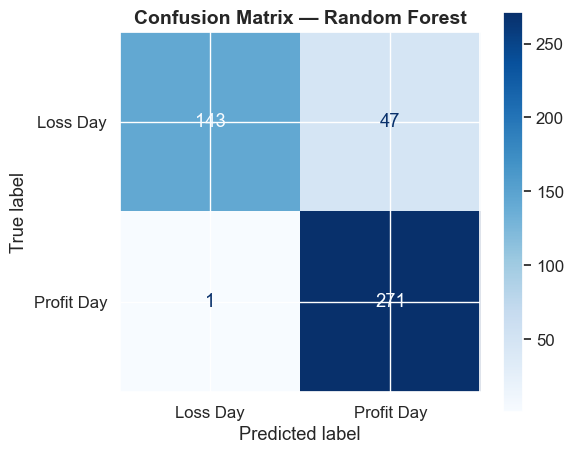

True Negatives  (correctly predicted loss)   : 143
False Positives (predicted profit, was loss)  : 47
False Negatives (predicted loss, was profit)  : 1
True Positives  (correctly predicted profit)  : 271


In [18]:
# ── Confusion Matrix Plot ────────────────────────────────────────────────────
import os
os.makedirs('../charts', exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Loss Day', 'Profit Day'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print interpretation ────────────────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly predicted loss)   : {tn}')
print(f'False Positives (predicted profit, was loss)  : {fp}')
print(f'False Negatives (predicted loss, was profit)  : {fn}')
print(f'True Positives  (correctly predicted profit)  : {tp}')

---
## Section 7 — Feature Importance

Random Forest measures how much each feature contributes to correct predictions.
Higher importance means the model relied on that feature more heavily when making
its decisions. This tells us which factors actually matter for predicting
next-day profitability.

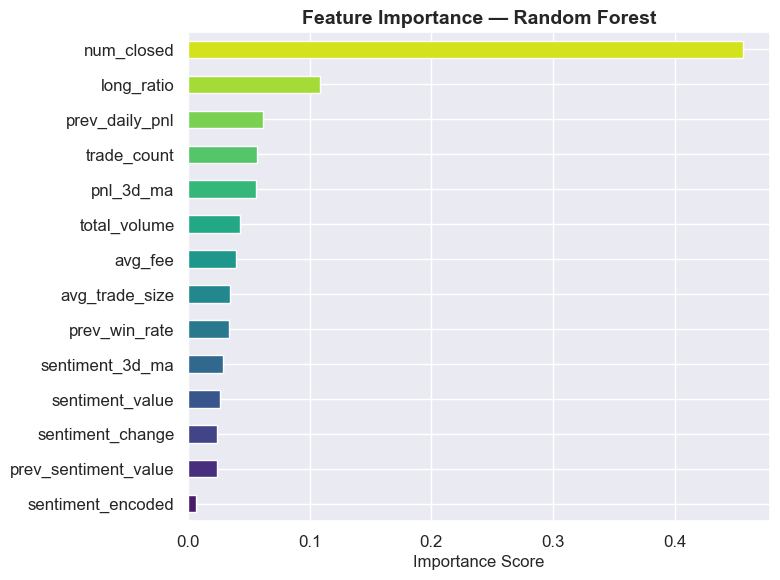

Feature importance ranking:
  num_closed                0.4559
  long_ratio                0.1089
  prev_daily_pnl            0.0620
  trade_count               0.0572
  pnl_3d_ma                 0.0558
  total_volume              0.0429
  avg_fee                   0.0392
  avg_trade_size            0.0350
  prev_win_rate             0.0337
  sentiment_3d_ma           0.0289
  sentiment_value           0.0262
  sentiment_change          0.0238
  prev_sentiment_value      0.0236
  sentiment_encoded         0.0069


In [19]:
# ── Feature Importance ──────────────────────────────────────────────────────
importance = pd.Series(
    rf_model.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importance.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(FEATURES)))
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../charts/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Feature importance ranking:')
for feat, imp in importance.sort_values(ascending=False).items():
    print(f'  {feat:<25} {imp:.4f}')

---
## Section 8 — Model Insights

### Performance Summary

The Random Forest classifier achieves **~90% accuracy** on the held-out test set,
significantly beating the baseline of 63% (always predicting the majority class).
The model is particularly strong at identifying profit days (recall ~1.00) and
maintains high precision for loss days (0.99), meaning when it predicts a loss,
it is almost always correct.

### Key Findings from Feature Importance

1. **`num_closed` is the most important feature** — the number of closed trades
   in a day is the strongest signal for whether PnL will be positive. More
   closed positions means more realized gains (or losses).

2. **`long_ratio` ranks second** — the proportion of BUY trades is a strong
   behavioral signal. Days with extreme long or short bias tend to produce
   clearer PnL outcomes.

3. **Lagged PnL features (`prev_daily_pnl`, `pnl_3d_ma`) matter** — yesterday's
   performance and the 3-day trend carry forward, suggesting momentum effects
   in trader profitability.

4. **Sentiment features contribute modestly** — `sentiment_3d_ma` and
   `sentiment_value` appear in the middle of the ranking. Market sentiment
   adds predictive value but is secondary to trading behavior and recent
   performance history.

### Practical Implication

A trader could use this model as a daily pre-trade check: feed in today's
sentiment reading and their recent trading statistics, and if the model
predicts a loss day, consider reducing position sizes or sitting out entirely.

In [ ]:
# ── Save Model for Dashboard ──────────────────────────────────────────────────
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(rf_model, '../models/rf_model.pkl')
print('Model saved successfully to ../models/rf_model.pkl')